In [1]:
# -------------------------
# IMPORTS
# -------------------------
 
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from collections import Counter
 
warnings.filterwarnings("ignore")

In [2]:
# -------------------------
# CONFIG
# -------------------------
 
INPUT_PATH  = "Attack_Dataset_Cleaned.csv"
OUTPUT_DIR  = "cybersecurity_outputs"
TOP_N       = 15
RANDOM_SEED = 42

In [3]:
# ensure output dir exists
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [4]:
# colour palette — dark security theme
BG      = "#0D1117"
PANEL   = "#161B22"
BORDER  = "#21262D"
SUBTEXT = "#8B949E"
TEXT    = "#E6EDF3"
GRID    = "#21262D"
 
PALETTE = [
    "#FF4757", "#FF6B35", "#FFD93D", "#6BCB77", "#4ECDC4",
    "#45B7D1", "#A855F7", "#EC4899", "#FF8C42", "#06D6A0",
    "#118AB2", "#EF476F", "#FFB703", "#8338EC", "#3A86FF",
]

In [5]:
def detect_col(cols, candidates):
    """Return first column name in cols that contains any candidate substring (case-insensitive)."""
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        for c_lower, c_orig in cols_lower.items():
            if cand.lower() in c_lower:
                return c_orig
    return None

In [6]:
def style_ax(ax, title=""):
    """Apply consistent dark theme styling to a matplotlib Axes object."""
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
        spine.set_linewidth(0.8)
    ax.tick_params(colors=SUBTEXT, labelsize=9)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, color=TEXT, fontsize=11, fontweight="bold", pad=12, loc="left")

In [8]:
def save_fig(fig, filename):
    """Save figure to OUTPUT_DIR with consistent settings."""
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG, edgecolor="none")
    
    print(f"  Saved → {path}")
    return path

In [9]:
# -------------------------
# LOAD DATA
# -------------------------
 
df = pd.read_csv(INPUT_PATH)
 
print("Shape:", df.shape)
df.head()

Shape: (13867, 16)


,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Notes
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 - Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 - Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 - Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 - SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN


In [10]:
# -------------------------
# COLUMN DETECTION
# -------------------------
 
# auto-detect key columns in case names differ
COL_CATEGORY  = detect_col(df.columns, ["category"])
COL_ATTACK    = detect_col(df.columns, ["attack type", "attack_type"])
COL_TARGET    = detect_col(df.columns, ["target type", "target_type"])
COL_MITRE     = detect_col(df.columns, ["mitre"])
COL_IMPACT    = detect_col(df.columns, ["impact"])
COL_DETECTION = detect_col(df.columns, ["detection"])
COL_SOURCE    = detect_col(df.columns, ["source"])
COL_SOLUTION  = detect_col(df.columns, ["solution"])

In [11]:
print("Detected columns:")
for name, col in [
    ("Category",  COL_CATEGORY),  ("Attack Type", COL_ATTACK),
    ("Target",    COL_TARGET),    ("MITRE",        COL_MITRE),
    ("Impact",    COL_IMPACT),    ("Detection",    COL_DETECTION),
    ("Source",    COL_SOURCE),    ("Solution",     COL_SOLUTION),
]:
    
    print(f"  {name:<14}: {col}")

Detected columns:
  Category      : Category
  Attack Type   : Attack Type
  Target        : Target Type
  MITRE         : MITRE Technique
  Impact        : Impact
  Detection     : Detection Method
  Source        : Source
  Solution      : Solution


In [12]:
# -------------------------
# BASIC EDA
# -------------------------
 
print("\n--- Dataset Overview ---")
print(f"Total records    : {len(df):,}")
print(f"Total columns    : {df.shape[1]}")
print(f"Categories       : {df[COL_CATEGORY].nunique()}")
print(f"Unique attack types: {df[COL_ATTACK].nunique():,}")
 
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
 
print("\n--- Data Types ---")
print(df.dtypes)
 
df.describe(include="all")


--- Dataset Overview ---
Total records    : 13,867
Total columns    : 16
Categories       : 63
Unique attack types: 8,834

--- Missing Values ---
Tools Used             14
Target Type             4
Vulnerability          17
MITRE Technique        20
Impact                  3
Detection Method        4
Solution                3
Tags                    3
Source                  1
Notes               13821
dtype: int64

--- Data Types ---
ID                       int64
Title                   object
Category                object
Attack Type             object
Scenario Description    object
Tools Used              object
Attack Steps            object
Target Type             object
Vulnerability           object
MITRE Technique         object
Impact                  object
Detection Method        object
Solution                object
Tags                    object
Source                  object
Notes                   object
dtype: object


,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Notes
count,13867.000000,13867,13867,13867,13867,13853,13867,13863,13850,13847,13864,13863,13864,13864,13866,46
unique,NaN,13793,63,8834,13866,12930,13867,9885,13408,5639,13174,13796,13833,13817,7052,2
top,NaN,Correlation Power Analysis (CPA),Physical / Hardware Attacks,Hardware Interface Exploitation,Using libFuzzer to fuzz argument parsing in ne...,Velociraptor,1. Reconnaissance: Find a login form on the we...,Windows,Use-After-Free,T1203,Credential theft,Registry + Prefetch + Memory,Quarantine + Block,"GPS spoofing, mobile fraud",Simulated,Educational Simulation
freq,NaN,3,548,161,2,18,1,291,21,343,36,9,4,3,2289,45
mean,7024.382635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4083.685903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3486.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10549.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# -------------------------
# BASIC EDA
# -------------------------
 
print("\n--- Dataset Overview ---")
print(f"Total records    : {len(df):,}")
print(f"Total columns    : {df.shape[1]}")
print(f"Categories       : {df[COL_CATEGORY].nunique()}")
print(f"Unique attack types: {df[COL_ATTACK].nunique():,}")
 
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
 
print("\n--- Data Types ---")
print(df.dtypes)
 
df.describe(include="all")


--- Dataset Overview ---
Total records    : 13,867
Total columns    : 16
Categories       : 63
Unique attack types: 8,834

--- Missing Values ---
Tools Used             14
Target Type             4
Vulnerability          17
MITRE Technique        20
Impact                  3
Detection Method        4
Solution                3
Tags                    3
Source                  1
Notes               13821
dtype: int64

--- Data Types ---
ID                       int64
Title                   object
Category                object
Attack Type             object
Scenario Description    object
Tools Used              object
Attack Steps            object
Target Type             object
Vulnerability           object
MITRE Technique         object
Impact                  object
Detection Method        object
Solution                object
Tags                    object
Source                  object
Notes                   object
dtype: object


,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Notes
count,13867.000000,13867,13867,13867,13867,13853,13867,13863,13850,13847,13864,13863,13864,13864,13866,46
unique,NaN,13793,63,8834,13866,12930,13867,9885,13408,5639,13174,13796,13833,13817,7052,2
top,NaN,Correlation Power Analysis (CPA),Physical / Hardware Attacks,Hardware Interface Exploitation,Using libFuzzer to fuzz argument parsing in ne...,Velociraptor,1. Reconnaissance: Find a login form on the we...,Windows,Use-After-Free,T1203,Credential theft,Registry + Prefetch + Memory,Quarantine + Block,"GPS spoofing, mobile fraud",Simulated,Educational Simulation
freq,NaN,3,548,161,2,18,1,291,21,343,36,9,4,3,2289,45
mean,7024.382635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4083.685903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3486.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10549.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# -------------------------
# FEATURE ENGINEERING
# -------------------------
 
# group 8,833+ raw attack types into 19 attack families
def assign_attack_family(attack_type):
    """Map a raw attack_type string to a high-level attack family."""
    if pd.isna(attack_type):
        return "Other"
    a = str(attack_type).lower()
    if "sql injection" in a or "sqli" in a:                        return "SQL Injection"
    if "xss" in a or "cross-site script" in a:                     return "Cross-Site Scripting (XSS)"
    if "phishing" in a or "social engineer" in a:                  return "Phishing / Social Engineering"
    if "brute force" in a or "password spray" in a:                return "Brute Force / Credential Attack"
    if "ransomware" in a:                                           return "Ransomware"
    if "privilege escalation" in a:                                 return "Privilege Escalation"
    if "denial of service" in a or "ddos" in a or " dos" in a:     return "Denial of Service (DoS/DDoS)"
    if "malware" in a or "trojan" in a or "backdoor" in a:         return "Malware / Trojan / Backdoor"
    if "ssrf" in a:                                                 return "SSRF"
    if "supply chain" in a:                                         return "Supply Chain Attack"
    if "credential" in a:                                           return "Credential Theft / Stuffing"
    if "lateral movement" in a:                                     return "Lateral Movement"
    if "man-in-the-middle" in a or "mitm" in a:                    return "Man-in-the-Middle (MITM)"
    if "fuzzing" in a:                                              return "Fuzzing"
    if "prompt injection" in a:                                     return "Prompt Injection (AI/LLM)"
    if "poison" in a:                                               return "Data / Model Poisoning"
    if "recon" in a or "reconnaissance" in a:                       return "Reconnaissance"
    if "exfil" in a:                                                return "Data Exfiltration"
    if "buffer overflow" in a or "heap overflow" in a:             return "Buffer / Heap Overflow"
    if "injection" in a:                                            return "Other Injection Attacks"
    return "Other"
 
 
df["attack_family"] = df[COL_ATTACK].apply(assign_attack_family)

In [15]:
# flag high impact records

HIGH_IMPACT_KEYWORDS = [
    "data theft", "privilege escalation", "ransomware",
    "account takeover", "remote code execution"
]
 
def is_high_impact(impact_val):
    if pd.isna(impact_val):
        return False
    impact_lower = str(impact_val).lower()
    return any(kw in impact_lower for kw in HIGH_IMPACT_KEYWORDS)
 
df["is_high_impact"] = df[COL_IMPACT].apply(is_high_impact)
 
# has_detection flag
df["has_detection"] = df[COL_DETECTION].apply(
    lambda x: 0 if (pd.isna(x) or str(x).strip() == "") else 1
)
 
print("Feature engineering complete.")
print(f"  Attack families : {df['attack_family'].nunique()}")
print(f"  High impact rows: {df['is_high_impact'].sum():,}")
print(f"  Has detection   : {df['has_detection'].sum():,} / {len(df):,}")

Feature engineering complete.
  Attack families : 21
  High impact rows: 1,044
  Has detection   : 13,863 / 13,867


In [16]:
# -------------------------
# ANALYSIS — CATEGORY
# -------------------------
 
cat_counts = (
    df[COL_CATEGORY]
    .value_counts()
    .reset_index()
)
cat_counts.columns = ["category", "total_attacks"]
cat_counts["pct_of_total"] = (cat_counts["total_attacks"] / len(df) * 100).round(2)
 
print(f"\nTop {TOP_N} categories:")
print(cat_counts.head(TOP_N).to_string(index=False))


Top 15 categories:
                                   category  total_attacks  pct_of_total
                Physical / Hardware Attacks            548          3.95
Quantum Cryptography & Post-Quantum Threats            542          3.91
                           Malware & Threat            528          3.81
                Wireless Attacks (Advanced)            520          3.75
                             Insider Threat            514          3.71
                                  Blue Team            503          3.63
                       Cryptography Attacks            501          3.61
        Email & Messaging Protocol Exploits            500          3.61
                            Mobile Security            499          3.60
            AI Data Leakage & Privacy Risks            499          3.60
                          Blockchain / Web3            499          3.60
                  Operating System Exploits            498          3.59
                             Cl

In [17]:
# -------------------------
# ANALYSIS — ATTACK FAMILIES
# -------------------------
 
family_counts = (
    df[df["attack_family"] != "Other"]
    ["attack_family"]
    .value_counts()
    .reset_index()
)
family_counts.columns = ["attack_family", "total_attacks"]
 
print("\nAttack families (excl. Other):")
print(family_counts.to_string(index=False))


Attack families (excl. Other):
                  attack_family  total_attacks
        Other Injection Attacks            733
    Malware / Trojan / Backdoor            407
    Credential Theft / Stuffing            290
  Phishing / Social Engineering            237
                 Reconnaissance            227
           Privilege Escalation            224
         Data / Model Poisoning            184
            Supply Chain Attack            147
      Prompt Injection (AI/LLM)            124
              Data Exfiltration            123
                        Fuzzing            120
     Cross-Site Scripting (XSS)            117
       Man-in-the-Middle (MITM)            105
   Denial of Service (DoS/DDoS)             99
                           SSRF             93
Brute Force / Credential Attack             73
               Lateral Movement             66
                     Ransomware             56
                  SQL Injection             42
         Buffer / Heap Overf

In [18]:
# -------------------------
# ANALYSIS — TARGET TYPES
# -------------------------
 
target_counts = (
    df[
        df[COL_TARGET].notna() &
        ~df[COL_TARGET].str.contains("DATA BLEED", na=False) &
        (df[COL_TARGET].str.strip() != "")
    ]
    [COL_TARGET]
    .value_counts()
    .reset_index()
    .head(10)
)
target_counts.columns = ["target_type", "times_targeted"]
 
print("\nTop 10 targeted systems:")
print(target_counts.to_string(index=False))


Top 10 targeted systems:
        target_type  times_targeted
            Windows             291
        Workstation             109
          Satellite              78
           Endpoint              50
        Android App              46
       Windows Host              38
  Wireless Networks              36
Infotainment System              35
Windows Workstation              34
                PLC              33


In [19]:
# -------------------------
# ANALYSIS — HIGH IMPACT
# -------------------------
 
high_impact_by_cat = (
    df[df["is_high_impact"]]
    .groupby(COL_CATEGORY)
    .size()
    .reset_index(name="high_impact_attacks")
    .sort_values("high_impact_attacks", ascending=False)
    .head(10)
)
 
print("\nTop 10 categories by high impact attacks:")
print(high_impact_by_cat.to_string(index=False))


Top 10 categories by high impact attacks:
                           Category  high_impact_attacks
           Web Application Security                  150
                     AI/ML Security                  114
           AI Agents & LLM Exploits                   85
                     Cloud Security                   72
          Operating System Exploits                   51
                   Malware & Threat                   45
                    Mobile Security                   44
Email & Messaging Protocol Exploits                   40
                           Red Team                   40
               Cryptography Attacks                   36


In [20]:
# -------------------------
# ANALYSIS — MITRE
# -------------------------
 
mitre_counts = (
    df[df[COL_MITRE].notna() & (df[COL_MITRE].str.strip() != "")]
    [COL_MITRE]
    .value_counts()
    .reset_index()
    .head(10)
)
mitre_counts.columns = ["mitre_technique", "frequency"]
 
print("\nTop 10 MITRE techniques:")
print(mitre_counts.to_string(index=False))


Top 10 MITRE techniques:
                              mitre_technique  frequency
                                        T1203        343
                                    T1552.001        209
                                    T1195.002        136
                                        T1499        120
                                        T1189        113
           T1499 - Endpoint Denial of Service         97
                                        T1609         91
    T1190 - Exploit Public-Facing Application         80
T1203 - Exploitation for Privilege Escalation         78
                                    T1204.002         73


In [21]:
# -------------------------
# ANALYSIS — SOURCES
# -------------------------
 
def group_source(src):
    """Group raw source strings into known security framework buckets."""
    if pd.isna(src) or str(src).strip() in ["", "Unknown"]:
        return "No Source"
    s = str(src)
    if "OWASP"  in s: return "OWASP"
    if "MITRE"  in s: return "MITRE ATT&CK"
    if "CVE"    in s or "NVD" in s: return "CVE/NVD"
    if "NIST"   in s: return "NIST"
    return "Other Sources"
 
df["source_group"] = df[COL_SOURCE].apply(group_source)
 
source_counts = (
    df["source_group"]
    .value_counts()
    .reset_index()
)
source_counts.columns = ["source_group", "total"]
 
print("\nSource distribution:")
print(source_counts.to_string(index=False))


Source distribution:
 source_group  total
Other Sources   9839
        OWASP   2497
 MITRE ATT&CK   1129
      CVE/NVD    163
    No Source    160
         NIST     79


In [22]:
# -------------------------
# ANALYSIS — IMPACTS
# -------------------------
 
impact_counts = (
    df[df[COL_IMPACT].notna() & (df[COL_IMPACT].str.strip() != "")]
    [COL_IMPACT]
    .str.strip()
    .str.title()
    .value_counts()
    .reset_index()
    .head(TOP_N)
)
impact_counts.columns = ["impact_type", "frequency"]
 
print("\nTop impacts:")
print(impact_counts.to_string(index=False))


Top impacts:
                 impact_type  frequency
            Credential Theft         65
       Remote Code Execution         45
                       T0856         18
         Unauthorized Access         17
      Full System Compromise         16
    Arbitrary Code Execution         15
          Account Compromise         15
                       T0884         12
              Code Execution         12
        Privilege Escalation         11
       Credential Harvesting         10
Unauthorized Physical Access         10
           Data Exfiltration         10
           Memory Corruption          9
           Denial Of Service          9


  Saved → cybersecurity_outputs\01_attacks_by_category.png


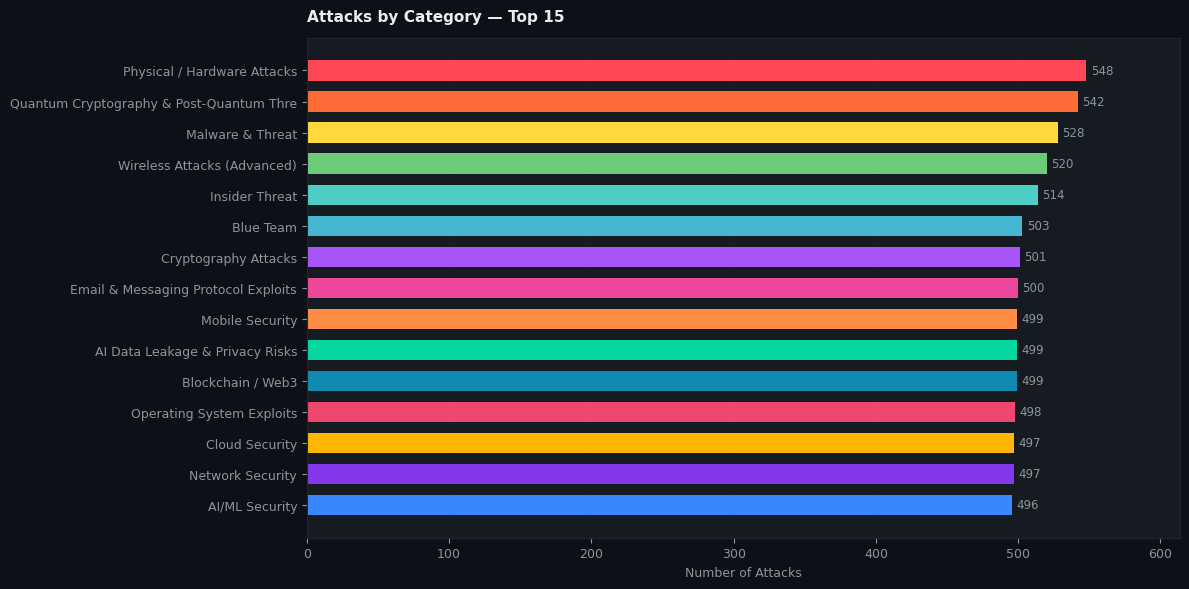

In [23]:
# =========================================================
# VISUALISATIONS
# =========================================================
 
 
# -------------------------
# CHART 1: Attacks by Category (Top 15)
# -------------------------
 
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, "Attacks by Category — Top 15")
 
top_cats   = cat_counts.head(15)
labels     = [c[:40] for c in top_cats["category"]]
values     = top_cats["total_attacks"].tolist()
bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(labels))]
 
bars = ax.barh(labels[::-1], values[::-1], color=bar_colors[::-1], height=0.65, edgecolor="none")
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(val), color=SUBTEXT, va="center", fontsize=8.5)
 
ax.set_xlabel("Number of Attacks", color=SUBTEXT, fontsize=9)
ax.set_xlim(0, max(values) * 1.12)
ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "01_attacks_by_category.png")
plt.show()

  Saved → cybersecurity_outputs\02_attack_type_families.png


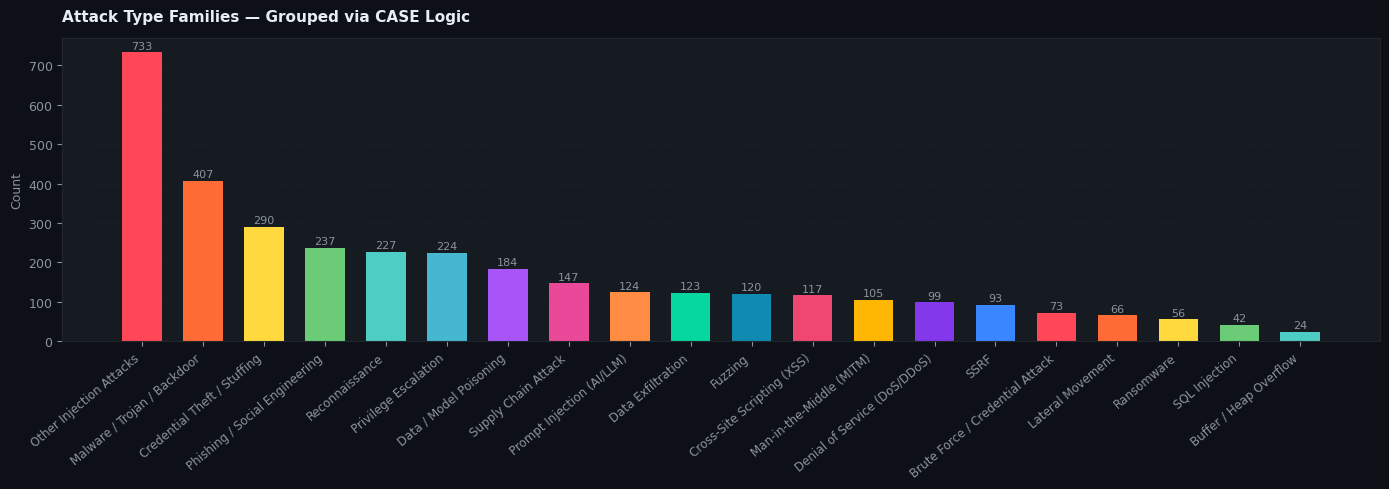

In [24]:
# -------------------------
# CHART 2: Attack Type Families
# -------------------------
 
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
style_ax(ax, "Attack Type Families — Grouped via CASE Logic")
 
fam_labels = family_counts["attack_family"].tolist()
fam_values = family_counts["total_attacks"].tolist()
x          = np.arange(len(fam_labels))
bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(fam_labels))]
 
bars = ax.bar(x, fam_values, color=bar_colors, width=0.65, edgecolor="none")
for bar, val in zip(bars, fam_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
            str(val), color=SUBTEXT, ha="center", va="bottom", fontsize=8)
 
ax.set_xticks(x)
ax.set_xticklabels(fam_labels, rotation=40, ha="right", fontsize=8.5)
ax.set_ylabel("Count", color=SUBTEXT, fontsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
plt.tight_layout()
save_fig(fig, "02_attack_type_families.png")
plt.show()

  Saved → cybersecurity_outputs\03_most_targeted_systems.png


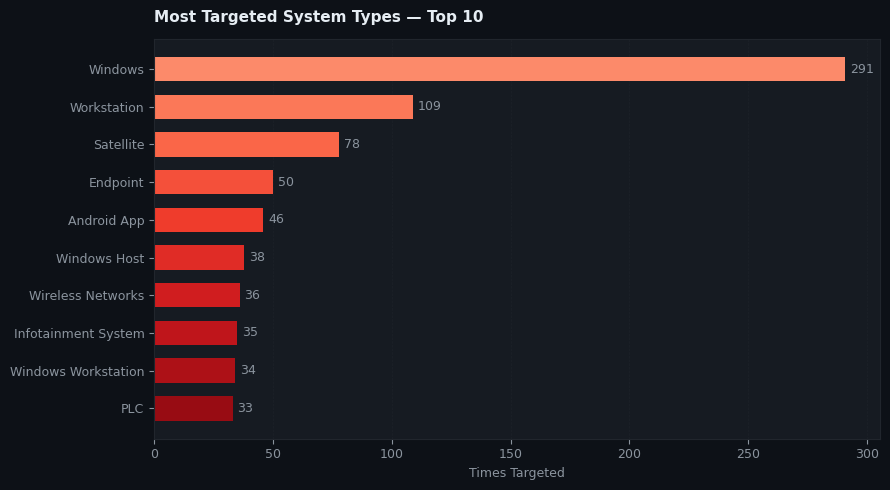

In [25]:
# -------------------------
# CHART 3: Most Targeted Systems
# -------------------------
 
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
style_ax(ax, "Most Targeted System Types — Top 10")
 
tgt_labels = target_counts["target_type"].tolist()
tgt_values = target_counts["times_targeted"].tolist()
colors     = plt.cm.Reds(np.linspace(0.4, 0.9, len(tgt_labels)))[::-1]
 
bars = ax.barh(tgt_labels[::-1], tgt_values[::-1], color=colors, height=0.65, edgecolor="none")
for bar, val in zip(bars, tgt_values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), color=SUBTEXT, va="center", fontsize=9)
 
ax.set_xlabel("Times Targeted", color=SUBTEXT, fontsize=9)
ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "03_most_targeted_systems.png")
plt.show()

  Saved → cybersecurity_outputs\04_high_impact_by_category.png


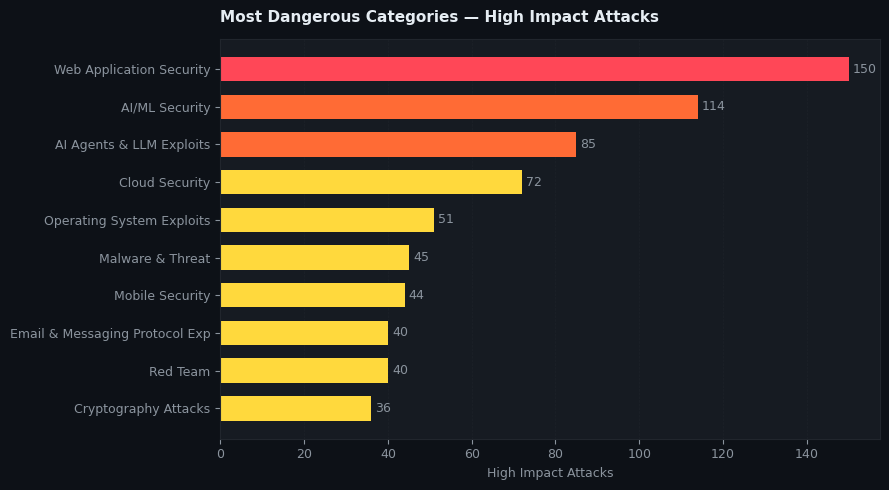

In [26]:
# -------------------------
# CHART 4: High Impact Attacks by Category
# -------------------------
 
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
style_ax(ax, "Most Dangerous Categories — High Impact Attacks")
 
hi_labels = [c[:30] for c in high_impact_by_cat[COL_CATEGORY].tolist()]
hi_values = high_impact_by_cat["high_impact_attacks"].tolist()
hi_colors = ["#FF4757" if v == max(hi_values) else "#FF6B35" if v >= 80 else "#FFD93D"
             for v in hi_values]
 
bars = ax.barh(hi_labels[::-1], hi_values[::-1], color=hi_colors[::-1],
               height=0.65, edgecolor="none")
for bar, val in zip(bars, hi_values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), color=SUBTEXT, va="center", fontsize=9)
 
ax.set_xlabel("High Impact Attacks", color=SUBTEXT, fontsize=9)
ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "04_high_impact_by_category.png")
plt.show()

  Saved → cybersecurity_outputs\05_mitre_techniques.png


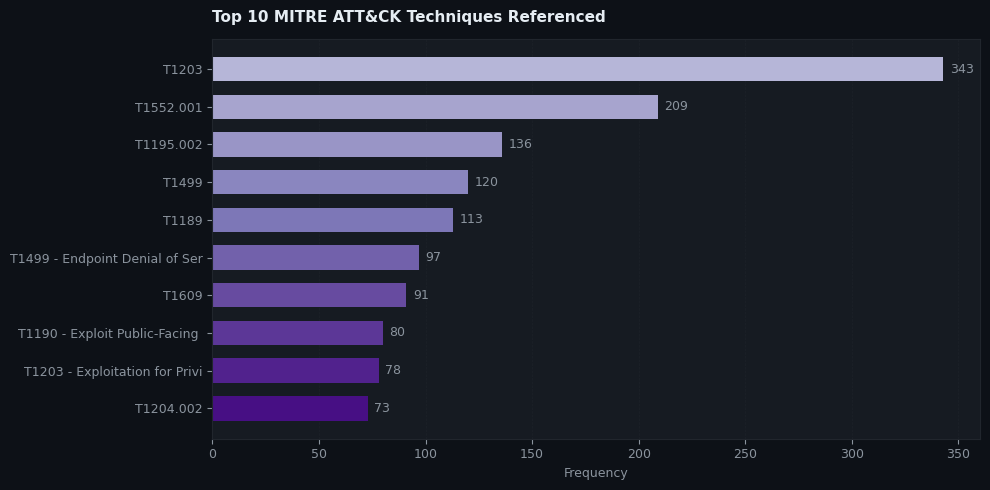

In [27]:
# -------------------------
# CHART 5: MITRE Techniques
# -------------------------
 
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
style_ax(ax, "Top 10 MITRE ATT&CK Techniques Referenced")
 
mit_labels = [m[:30] for m in mitre_counts["mitre_technique"].tolist()]
mit_values = mitre_counts["frequency"].tolist()
colors     = plt.cm.Purples(np.linspace(0.4, 0.95, len(mit_labels)))[::-1]
 
bars = ax.barh(mit_labels[::-1], mit_values[::-1], color=colors,
               height=0.65, edgecolor="none")
for bar, val in zip(bars, mit_values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(val), color=SUBTEXT, va="center", fontsize=9)
 
ax.set_xlabel("Frequency", color=SUBTEXT, fontsize=9)
ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "05_mitre_techniques.png")
plt.show()

  Saved → cybersecurity_outputs\06_source_distribution.png


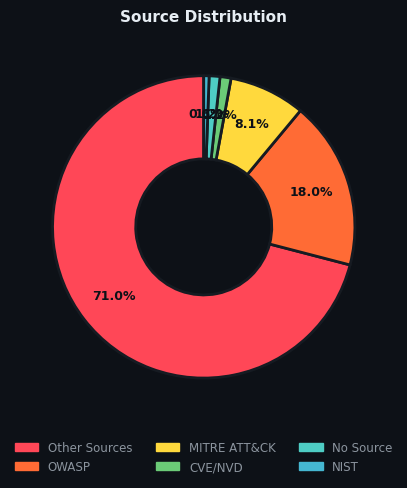

In [28]:
# -------------------------
# CHART 6: Source Distribution (Donut)
# -------------------------
 
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)
ax.set_title("Source Distribution", color=TEXT, fontsize=11, fontweight="bold", pad=12)
 
src_labels = source_counts["source_group"].tolist()
src_values = source_counts["total"].tolist()
src_colors = ["#FF4757", "#FF6B35", "#FFD93D", "#6BCB77", "#4ECDC4", "#45B7D1"]
 
wedges, texts, autotexts = ax.pie(
    src_values, labels=None, colors=src_colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=PANEL, linewidth=2),
    pctdistance=0.75
)
for t in autotexts:
    t.set_color(BG)
    t.set_fontsize(9)
    t.set_fontweight("bold")
 
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(src_colors, src_labels)]
ax.legend(handles=legend_patches, loc="lower center",
          bbox_to_anchor=(0.5, -0.18), ncol=3,
          fontsize=8.5, frameon=False, labelcolor=SUBTEXT)
 
plt.tight_layout()
save_fig(fig, "06_source_distribution.png")
plt.show()

  Saved → cybersecurity_outputs\07_common_impacts.png


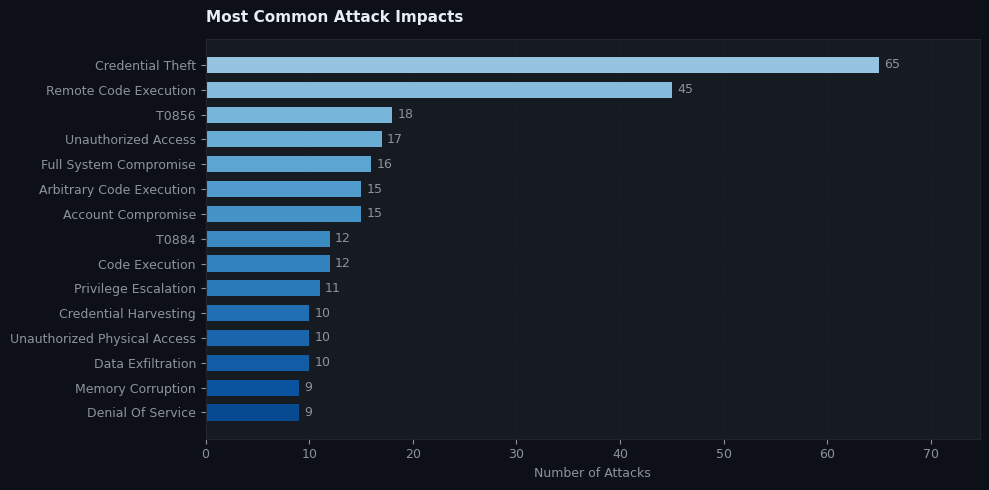

In [29]:
# -------------------------
# CHART 7: Common Impacts
# -------------------------
 
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
style_ax(ax, "Most Common Attack Impacts")
 
imp_labels = [i[:35] for i in impact_counts["impact_type"].tolist()]
imp_values = impact_counts["frequency"].tolist()
colors     = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_labels)))[::-1]
 
bars = ax.barh(imp_labels[::-1], imp_values[::-1], color=colors,
               height=0.65, edgecolor="none")
for bar, val in zip(bars, imp_values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), color=SUBTEXT, va="center", fontsize=9)
 
ax.set_xlabel("Number of Attacks", color=SUBTEXT, fontsize=9)
ax.set_xlim(0, max(imp_values) * 1.15)
ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "07_common_impacts.png")
plt.show()

  Saved → cybersecurity_outputs\08_detection_coverage.png


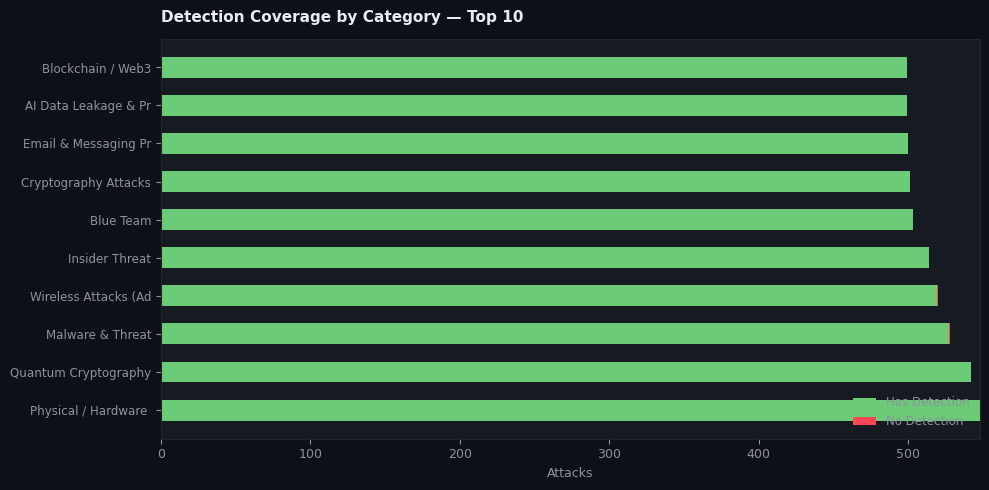

In [30]:
# -------------------------
# CHART 8: Detection Coverage
# -------------------------
 
det_summary = (
    df.groupby(COL_CATEGORY)
    .agg(
        has_detection=("has_detection", "sum"),
        total=("has_detection", "count")
    )
    .reset_index()
    .sort_values("total", ascending=False)
    .head(10)
)
det_summary["no_detection"] = det_summary["total"] - det_summary["has_detection"]
 
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
style_ax(ax, "Detection Coverage by Category — Top 10")
 
y_pos  = np.arange(len(det_summary))
labels = [c[:20] for c in det_summary[COL_CATEGORY].tolist()]
 
ax.barh(y_pos, det_summary["has_detection"], color="#6BCB77",
        height=0.55, edgecolor="none", label="Has Detection")
ax.barh(y_pos, det_summary["no_detection"],
        left=det_summary["has_detection"], color="#FF4757",
        height=0.55, edgecolor="none", label="No Detection")
 
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel("Attacks", color=SUBTEXT, fontsize=9)
ax.legend(loc="lower right", fontsize=8.5, frameon=False, labelcolor=SUBTEXT)
ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "08_detection_coverage.png")
plt.show()

  Saved → cybersecurity_outputs\00_full_dashboard.png


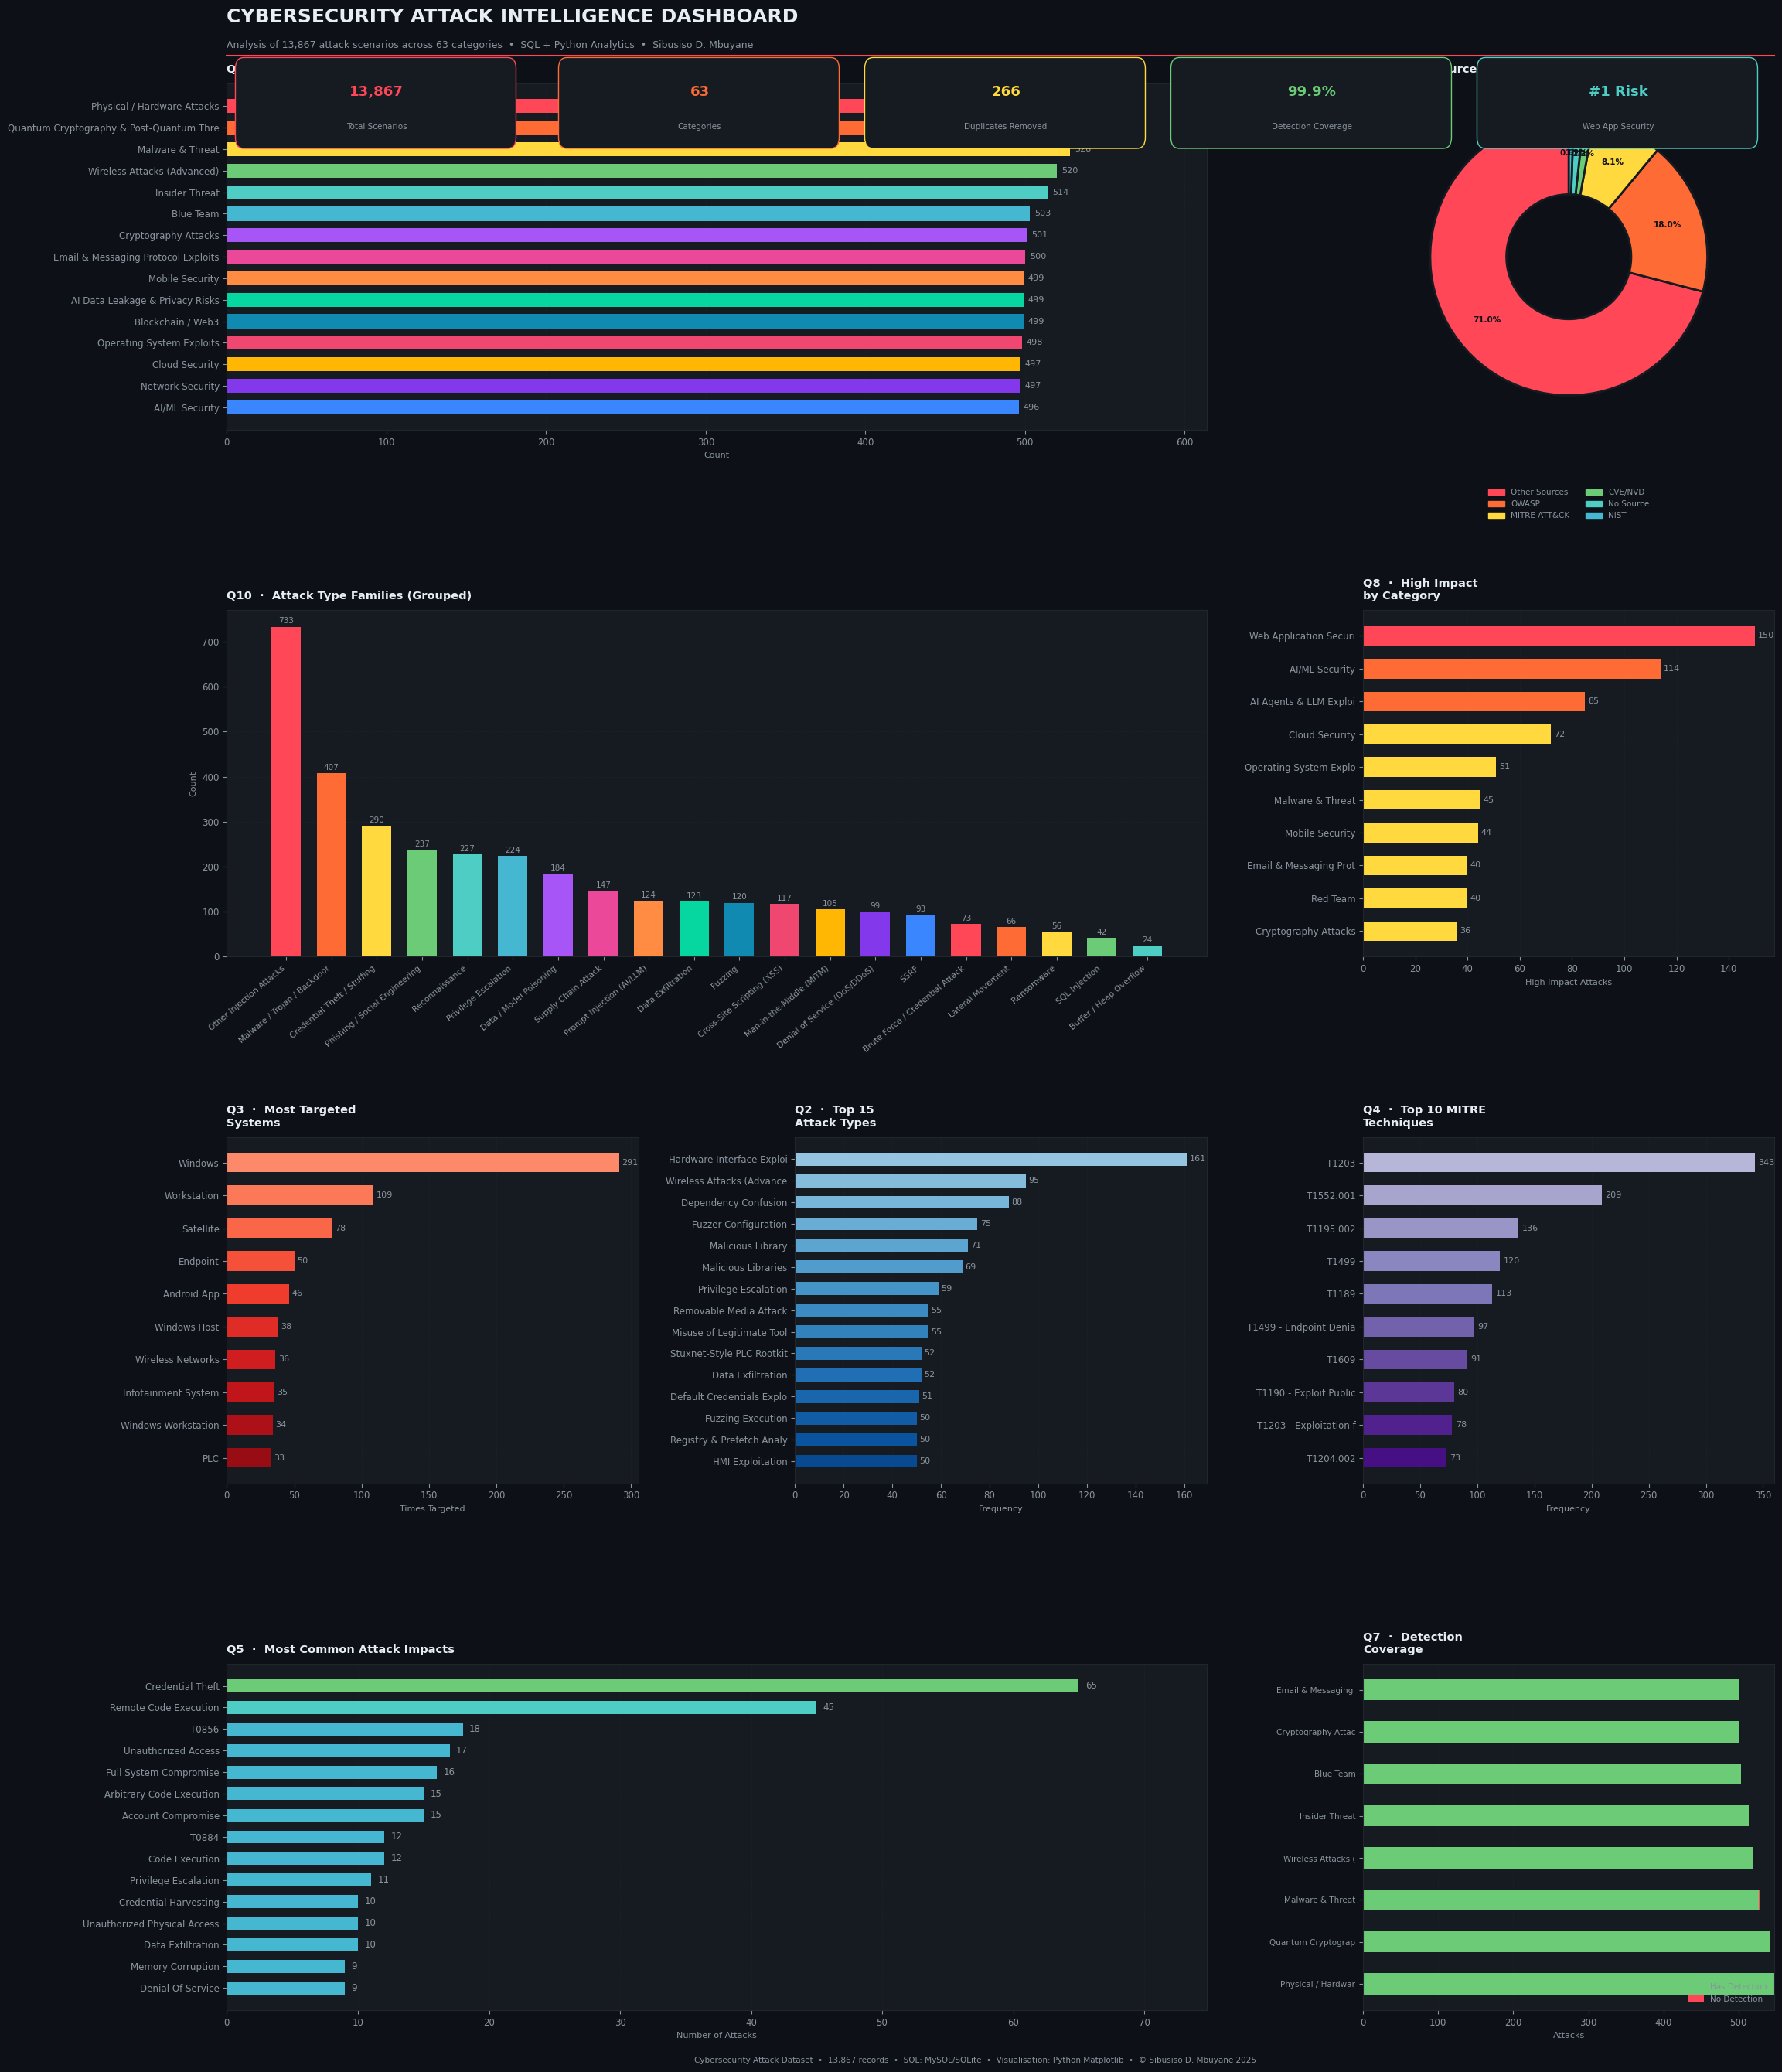


All charts saved to: cybersecurity_outputs


In [31]:
# =========================================================
# FULL DASHBOARD (all charts in one figure)
# =========================================================
 
# -------------------------
# DASHBOARD: Multi-panel
# -------------------------
 
fig = plt.figure(figsize=(22, 28), facecolor=BG)
gs  = gridspec.GridSpec(4, 3, figure=fig,
                        hspace=0.52, wspace=0.38,
                        top=0.93, bottom=0.04,
                        left=0.06, right=0.97)
 
# header text
fig.text(0.06, 0.965, "CYBERSECURITY ATTACK INTELLIGENCE DASHBOARD",
         color=TEXT, fontsize=18, fontweight="bold", va="top")
fig.text(0.06, 0.950,
         f"Analysis of {len(df):,} attack scenarios across "
         f"{df[COL_CATEGORY].nunique()} categories  •  "
         "SQL + Python Analytics  •  Sibusiso D. Mbuyane",
         color=SUBTEXT, fontsize=9, va="top")
 
line = plt.Line2D([0.06, 0.97], [0.943, 0.943],
                  transform=fig.transFigure, color="#FF4757", linewidth=1.5)
fig.add_artist(line)
 
# KPI cards
kpis = [
    (f"{len(df):,}", "Total Scenarios"),
    (str(df[COL_CATEGORY].nunique()), "Categories"),
    ("266", "Duplicates Removed"),
    ("99.9%", "Detection Coverage"),
    ("#1 Risk", "Web App Security"),
]
kpi_positions = [0.07, 0.26, 0.44, 0.62, 0.80]
for i, ((val, label), xpos) in enumerate(zip(kpis, kpi_positions)):
    from matplotlib.patches import FancyBboxPatch
    rect = FancyBboxPatch((xpos, 0.905), 0.155, 0.032,
                          boxstyle="round,pad=0.005",
                          linewidth=1, edgecolor=PALETTE[i],
                          facecolor=PANEL,
                          transform=fig.transFigure, clip_on=False)
    fig.add_artist(rect)
    fig.text(xpos + 0.078, 0.926, val, color=PALETTE[i],
             fontsize=13, fontweight="bold", ha="center",
             va="center", transform=fig.transFigure)
    fig.text(xpos + 0.078, 0.910, label, color=SUBTEXT,
             fontsize=7.5, ha="center", va="center",
             transform=fig.transFigure)
 
def _style(ax, title):
    ax.set_facecolor(PANEL)
    for s in ax.spines.values():
        s.set_edgecolor(BORDER); s.set_linewidth(0.8)
    ax.tick_params(colors=SUBTEXT, labelsize=8.5)
    ax.set_title(title, color=TEXT, fontsize=10.5,
                 fontweight="bold", pad=10, loc="left")
    ax.grid(axis="y", color=GRID, linewidth=0.5,
            linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
 
# panel 1 — category
ax1 = fig.add_subplot(gs[0, :2])
_style(ax1, "Q1  ·  Attacks by Category (Top 15)")
top_cats_d = cat_counts.head(15)
lbs = [c[:40] for c in top_cats_d["category"]]
vls = top_cats_d["total_attacks"].tolist()
clrs = [PALETTE[i % len(PALETTE)] for i in range(len(lbs))]
brs = ax1.barh(lbs[::-1], vls[::-1], color=clrs[::-1], height=0.65, edgecolor="none")
for b, v in zip(brs, vls[::-1]):
    ax1.text(b.get_width() + 3, b.get_y() + b.get_height() / 2,
             str(v), color=SUBTEXT, va="center", fontsize=8)
ax1.set_xlabel("Count", color=SUBTEXT, fontsize=8)
ax1.set_xlim(0, max(vls) * 1.12)
ax1.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax1.grid(axis="y", visible=False)
 
# panel 2 — source donut
ax2 = fig.add_subplot(gs[0, 2])
_style(ax2, "Q9  ·  Source Distribution")
s_lbs = source_counts["source_group"].tolist()
s_vls = source_counts["total"].tolist()
s_clrs = PALETTE[:len(s_lbs)]
wedges, _, autotexts = ax2.pie(
    s_vls, colors=s_clrs, autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=PANEL, linewidth=2),
    pctdistance=0.75
)
for t in autotexts:
    t.set_color(BG); t.set_fontsize(7.5); t.set_fontweight("bold")
ax2.legend(
    handles=[mpatches.Patch(color=c, label=l) for c, l in zip(s_clrs, s_lbs)],
    loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2,
    fontsize=7.5, frameon=False, labelcolor=SUBTEXT
)
 
# panel 3 — attack families
ax3 = fig.add_subplot(gs[1, :2])
_style(ax3, "Q10  ·  Attack Type Families (Grouped)")
f_lbs = family_counts["attack_family"].tolist()
f_vls = family_counts["total_attacks"].tolist()
x3 = np.arange(len(f_lbs))
brs3 = ax3.bar(x3, f_vls, color=[PALETTE[i % len(PALETTE)] for i in range(len(f_lbs))],
               width=0.65, edgecolor="none")
for b, v in zip(brs3, f_vls):
    ax3.text(b.get_x() + b.get_width() / 2, b.get_height() + 4,
             str(v), color=SUBTEXT, ha="center", va="bottom", fontsize=7.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(f_lbs, rotation=40, ha="right", fontsize=7.8)
ax3.set_ylabel("Count", color=SUBTEXT, fontsize=8)
 
# panel 4 — high impact
ax4 = fig.add_subplot(gs[1, 2])
_style(ax4, "Q8  ·  High Impact\nby Category")
hi_lbs = [c[:22] for c in high_impact_by_cat[COL_CATEGORY].tolist()]
hi_vls = high_impact_by_cat["high_impact_attacks"].tolist()
hi_clrs = ["#FF4757" if v == max(hi_vls) else "#FF6B35" if v >= 80 else "#FFD93D"
           for v in hi_vls]
brs4 = ax4.barh(hi_lbs[::-1], hi_vls[::-1], color=hi_clrs[::-1],
                height=0.6, edgecolor="none")
for b, v in zip(brs4, hi_vls[::-1]):
    ax4.text(b.get_width() + 1, b.get_y() + b.get_height() / 2,
             str(v), color=SUBTEXT, va="center", fontsize=8)
ax4.set_xlabel("High Impact Attacks", color=SUBTEXT, fontsize=8)
ax4.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax4.grid(axis="y", visible=False)
 
# panel 5 — targets
ax5 = fig.add_subplot(gs[2, 0])
_style(ax5, "Q3  ·  Most Targeted\nSystems")
t_lbs = target_counts["target_type"].tolist()
t_vls = target_counts["times_targeted"].tolist()
t_clrs = plt.cm.Reds(np.linspace(0.4, 0.9, len(t_lbs)))[::-1]
brs5 = ax5.barh(t_lbs[::-1], t_vls[::-1], color=t_clrs, height=0.6, edgecolor="none")
for b, v in zip(brs5, t_vls[::-1]):
    ax5.text(b.get_width() + 2, b.get_y() + b.get_height() / 2,
             str(v), color=SUBTEXT, va="center", fontsize=8)
ax5.set_xlabel("Times Targeted", color=SUBTEXT, fontsize=8)
ax5.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax5.grid(axis="y", visible=False)
 
# panel 6 — top attack types
ax6 = fig.add_subplot(gs[2, 1])
_style(ax6, "Q2  ·  Top 15\nAttack Types")
at_counts = df[COL_ATTACK].value_counts().reset_index().head(15)
at_counts.columns = ["attack_type", "frequency"]
at_lbs = [a[:25] for a in at_counts["attack_type"].tolist()]
at_vls = at_counts["frequency"].tolist()
at_clrs = plt.cm.Blues(np.linspace(0.4, 0.9, len(at_lbs)))[::-1]
brs6 = ax6.barh(at_lbs[::-1], at_vls[::-1], color=at_clrs, height=0.6, edgecolor="none")
for b, v in zip(brs6, at_vls[::-1]):
    ax6.text(b.get_width() + 1, b.get_y() + b.get_height() / 2,
             str(v), color=SUBTEXT, va="center", fontsize=8)
ax6.set_xlabel("Frequency", color=SUBTEXT, fontsize=8)
ax6.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax6.grid(axis="y", visible=False)
 
# panel 7 — MITRE
ax7 = fig.add_subplot(gs[2, 2])
_style(ax7, "Q4  ·  Top 10 MITRE\nTechniques")
m_lbs = [m[:22] for m in mitre_counts["mitre_technique"].tolist()]
m_vls = mitre_counts["frequency"].tolist()
m_clrs = plt.cm.Purples(np.linspace(0.4, 0.95, len(m_lbs)))[::-1]
brs7 = ax7.barh(m_lbs[::-1], m_vls[::-1], color=m_clrs, height=0.6, edgecolor="none")
for b, v in zip(brs7, m_vls[::-1]):
    ax7.text(b.get_width() + 3, b.get_y() + b.get_height() / 2,
             str(v), color=SUBTEXT, va="center", fontsize=8)
ax7.set_xlabel("Frequency", color=SUBTEXT, fontsize=8)
ax7.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax7.grid(axis="y", visible=False)
 
# panel 8 — impacts
ax8 = fig.add_subplot(gs[3, :2])
_style(ax8, "Q5  ·  Most Common Attack Impacts")
i_lbs = [i[:35] for i in impact_counts["impact_type"].tolist()]
i_vls = impact_counts["frequency"].tolist()
i_clrs = ["#6BCB77" if v == max(i_vls) else "#4ECDC4" if v >= 40 else "#45B7D1"
          for v in i_vls]
brs8 = ax8.barh(i_lbs[::-1], i_vls[::-1], color=i_clrs[::-1], height=0.6, edgecolor="none")
for b, v in zip(brs8, i_vls[::-1]):
    ax8.text(b.get_width() + 0.5, b.get_y() + b.get_height() / 2,
             str(v), color=SUBTEXT, va="center", fontsize=8.5)
ax8.set_xlabel("Number of Attacks", color=SUBTEXT, fontsize=8)
ax8.set_xlim(0, max(i_vls) * 1.15)
ax8.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax8.grid(axis="y", visible=False)
 
# panel 9 — detection coverage
ax9 = fig.add_subplot(gs[3, 2])
_style(ax9, "Q7  ·  Detection\nCoverage")
det8 = det_summary.head(8)
y9   = np.arange(len(det8))
d_lbs = [c[:18] for c in det8[COL_CATEGORY].tolist()]
ax9.barh(y9, det8["has_detection"], color="#6BCB77",
         height=0.5, edgecolor="none", label="Has Detection")
ax9.barh(y9, det8["no_detection"], left=det8["has_detection"],
         color="#FF4757", height=0.5, edgecolor="none", label="No Detection")
ax9.set_yticks(y9)
ax9.set_yticklabels(d_lbs, fontsize=7.5)
ax9.set_xlabel("Attacks", color=SUBTEXT, fontsize=8)
ax9.legend(loc="lower right", fontsize=7.5, frameon=False, labelcolor=SUBTEXT)
ax9.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--", alpha=0.6)
ax9.grid(axis="y", visible=False)
 
# footer
fig.text(0.5, 0.015,
         f"Cybersecurity Attack Dataset  •  {len(df):,} records  •  "
         "SQL: MySQL/SQLite  •  Visualisation: Python Matplotlib  •  "
         "© Sibusiso D. Mbuyane 2025",
         color=SUBTEXT, fontsize=7.5, ha="center", va="bottom")
 
save_fig(fig, "00_full_dashboard.png")
plt.show()
 
print("\nAll charts saved to:", OUTPUT_DIR)